# TASK 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)


In [3]:
# Load datasets
train_df = pd.read_csv("pulsar_data_train.csv")
test_df = pd.read_csv("pulsar_data_test.csv")

# Basic EDA
print("Train Shape:", train_df.shape)
print("Class Distribution:\n", train_df['target_class'].value_counts())


Train Shape: (12528, 9)
Class Distribution:
 target_class
0.0    11375
1.0     1153
Name: count, dtype: int64


In [4]:
# Handle missing values
train_df.fillna(train_df.mean(), inplace=True)

# Split into features and target
X = train_df.drop(columns=["target_class"])
y = train_df["target_class"]

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [5]:
kernels = ['linear', 'poly', 'sigmoid']
models = {}
results = {}

for k in kernels:
    print(f"\n--- Kernel: {k.upper()} ---")
    model = SVC(kernel=k, probability=True, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]

    cm = confusion_matrix(y_val, y_pred)
    cr = classification_report(y_val, y_pred, output_dict=True)
    auc = roc_auc_score(y_val, y_proba)
    fpr, tpr, _ = roc_curve(y_val, y_proba)

    models[k] = model
    results[k] = {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'conf_matrix': cm,
        'class_report': cr,
        'auc': auc,
        'fpr': fpr,
        'tpr': tpr
    }

    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n", classification_report(y_val, y_pred))
    print("ROC AUC Score:", auc)



--- Kernel: LINEAR ---
Confusion Matrix:
 [[2268    7]
 [  45  186]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2275
         1.0       0.96      0.81      0.88       231

    accuracy                           0.98      2506
   macro avg       0.97      0.90      0.93      2506
weighted avg       0.98      0.98      0.98      2506

ROC AUC Score: 0.9680548023405167

--- Kernel: POLY ---
Confusion Matrix:
 [[2268    7]
 [  49  182]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2275
         1.0       0.96      0.79      0.87       231

    accuracy                           0.98      2506
   macro avg       0.97      0.89      0.93      2506
weighted avg       0.98      0.98      0.98      2506

ROC AUC Score: 0.9607364064506922

--- Kernel: SIGMOID ---
Confusion Matrix:
 [[2091  184]
 [ 157   74]]
Classification Report

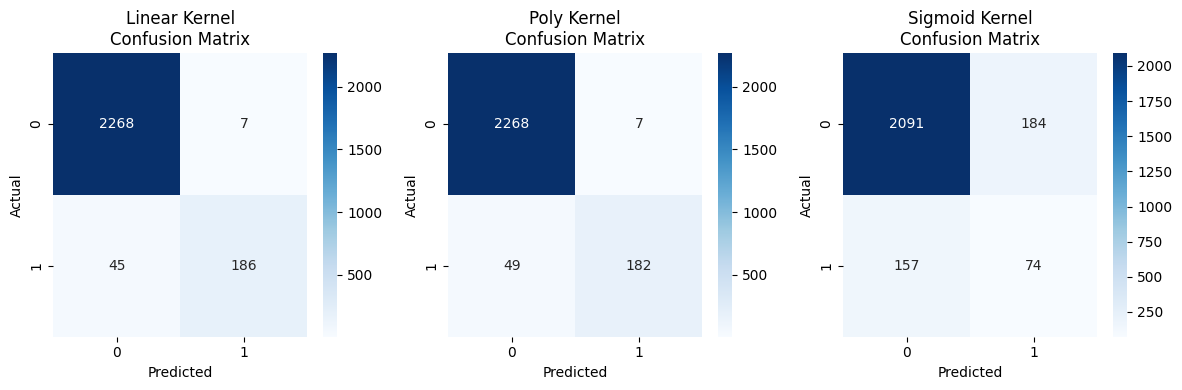

In [6]:
plt.figure(figsize=(12, 4))
for i, k in enumerate(kernels):
    plt.subplot(1, 3, i+1)
    sns.heatmap(results[k]['conf_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f"{k.capitalize()} Kernel\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
plt.tight_layout()
plt.show()


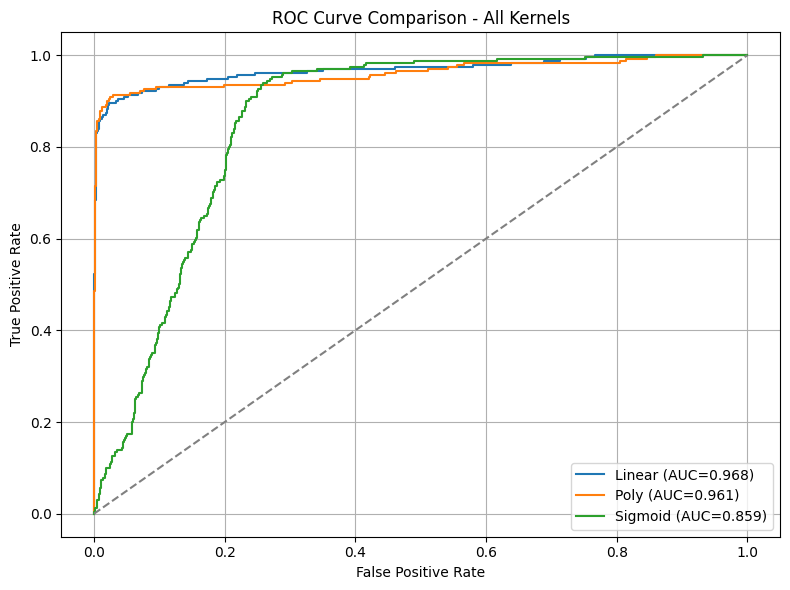

In [7]:
plt.figure(figsize=(8, 6))
for k in kernels:
    plt.plot(results[k]['fpr'], results[k]['tpr'], label=f"{k.capitalize()} (AUC={results[k]['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison - All Kernels")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
print("\n--- Stratified K-Fold Accuracy ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for k in kernels:
    scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_fold_train, X_fold_test = X.iloc[train_idx], X.iloc[test_idx]
        y_fold_train, y_fold_test = y.iloc[train_idx], y.iloc[test_idx]

        X_fold_train_scaled = scaler.fit_transform(X_fold_train)
        X_fold_test_scaled = scaler.transform(X_fold_test)

        model = SVC(kernel=k, random_state=42)
        model.fit(X_fold_train_scaled, y_fold_train)
        acc = model.score(X_fold_test_scaled, y_fold_test)
        scores.append(acc)

    print(f"{k.capitalize()} Kernel Avg Accuracy: {np.mean(scores):.4f}")



--- Stratified K-Fold Accuracy ---
Linear Kernel Avg Accuracy: 0.9761
Poly Kernel Avg Accuracy: 0.9744
Sigmoid Kernel Avg Accuracy: 0.8720


In [9]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear']
}
grid = GridSearchCV(SVC(probability=True, random_state=42), param_grid,
                    cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("\n--- Best Model After GridSearchCV ---")
print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_val_scaled)
y_proba_best = best_model.predict_proba(X_val_scaled)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred_best))
print("Classification Report:\n", classification_report(y_val, y_pred_best))
print("ROC AUC Score:", roc_auc_score(y_val, y_proba_best))



--- Best Model After GridSearchCV ---
Best Parameters: {'C': 10, 'kernel': 'linear'}
Best Cross-Validation Score: 0.9752542794709832
Confusion Matrix:
 [[2268    7]
 [  45  186]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.98      1.00      0.99      2275
         1.0       0.96      0.81      0.88       231

    accuracy                           0.98      2506
   macro avg       0.97      0.90      0.93      2506
weighted avg       0.98      0.98      0.98      2506

ROC AUC Score: 0.967978687978688


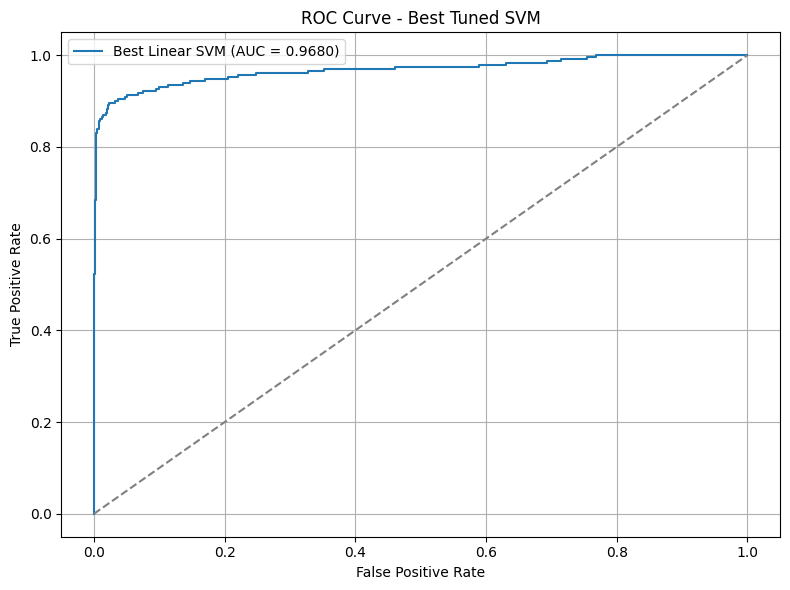

In [10]:
fpr, tpr, _ = roc_curve(y_val, y_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Best Linear SVM (AUC = {roc_auc_score(y_val, y_proba_best):.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Tuned SVM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [11]:
test_df.fillna(test_df.mean(), inplace=True)
X_test = test_df.drop(columns=['target_class'])
X_test_scaled = scaler.transform(X_test)
test_predictions = best_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'SampleID': np.arange(len(test_predictions)),
    'PredictedLabel': test_predictions.astype(int)
})
submission.to_csv("svm_pulsar_predictions.csv", index=False)
print("\nPredictions saved to 'svm_pulsar_predictions.csv'.")



Predictions saved to 'svm_pulsar_predictions.csv'.


# TASK 2

In [21]:
from datasets import load_dataset
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, confusion_matrix, mean_absolute_error, r2_score
)
from sklearn.utils import resample
from scipy.stats import mode


In [22]:
# --- Load and preprocess dataset (reduced size) ---
def load_and_prepare_data(name, train_size=3000, test_size=500):
    data = load_dataset(name)
    X = np.array([np.array(img).reshape(-1) for img in data['train']['image']])
    y = np.array(data['train']['label'])
    return train_test_split(X, y, train_size=train_size, test_size=test_size,
                            stratify=y, random_state=42)

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = load_and_prepare_data("mnist")
X_train_fmnist, X_test_fmnist, y_train_fmnist, y_test_fmnist = load_and_prepare_data("fashion_mnist")


In [23]:
# --- Bagging Classifier ---
def bagging_classifier(X_train, y_train, X_test, n_estimators=10):
    predictions = []
    for _ in range(n_estimators):
        X_sample, y_sample = resample(X_train, y_train, replace=True)
        clf = DecisionTreeClassifier()
        clf.fit(X_sample, y_sample)
        predictions.append(clf.predict(X_test))
    predictions = np.array(predictions)
    final_prediction, _ = mode(predictions, axis=0)
    return final_prediction.flatten()


In [24]:
# --- Softmax ---
def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)


In [25]:
# --- Custom Gradient Boosting Classifier ---
def gradient_boosting_regressor(X_train, y_train, X_test, n_estimators=20, learning_rate=0.1):
    num_classes = len(np.unique(y_train))
    y_train_oh = np.eye(num_classes)[y_train]
    y_pred = np.zeros((X_train.shape[0], num_classes))
    models = []

    for _ in range(n_estimators):
        residual = y_train_oh - softmax(y_pred)
        stage_models = []
        for k in range(num_classes):
            reg = DecisionTreeRegressor(max_depth=1)
            reg.fit(X_train, residual[:, k])
            y_pred[:, k] += learning_rate * reg.predict(X_train)
            stage_models.append(reg)
        models.append(stage_models)

    y_pred_test = np.zeros((X_test.shape[0], num_classes))
    for stage_models in models:
        for k in range(num_classes):
            y_pred_test[:, k] += learning_rate * stage_models[k].predict(X_test)

    final_preds = np.argmax(y_pred_test, axis=1)
    return final_preds


In [26]:
# --- Evaluation with heatmap ---
def evaluate_model(name, y_true, y_pred, is_boosting=False, show_plot=True):
    print(f"\n=== {name} ===")
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    if is_boosting:
        print("MAE:", mean_absolute_error(y_true, y_pred))
        print("R2 Score:", r2_score(y_true, y_pred))

    if show_plot:
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f"{name} Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()



=== MNIST - Bagging ===
Accuracy: 0.8420
Confusion Matrix:
[[43  0  2  0  1  2  1  0  0  0]
 [ 0 53  2  0  0  0  0  0  1  0]
 [ 1  1 42  0  1  0  2  0  2  1]
 [ 1  1  1 45  0  1  1  0  0  1]
 [ 0  2  1  1 41  1  0  1  0  2]
 [ 0  0  0  4  0 37  3  0  0  1]
 [ 0  1  1  1  1  4 38  0  3  0]
 [ 0  0  0  0  1  1  0 47  0  3]
 [ 1  3  2  2  0  3  1  0 37  0]
 [ 0  1  0  2  4  1  0  1  3 38]]


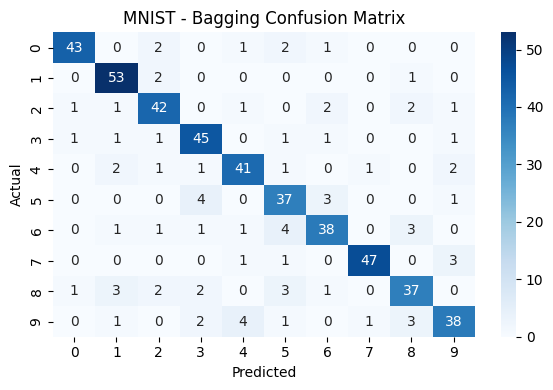


=== Fashion MNIST - Bagging ===
Accuracy: 0.7940
Confusion Matrix:
[[42  1  0  3  0  0  2  0  1  1]
 [ 0 48  0  1  0  0  0  0  1  0]
 [ 1  0 33  0 11  0  4  0  1  0]
 [ 5  1  0 44  0  0  0  0  0  0]
 [ 0  0  5  5 34  0  5  0  1  0]
 [ 0  0  0  0  0 42  1  4  1  2]
 [10  0  7  0  6  0 26  0  1  0]
 [ 0  0  0  0  0  7  0 41  0  2]
 [ 0  0  1  0  0  1  0  1 47  0]
 [ 1  0  0  0  0  0  0  5  4 40]]


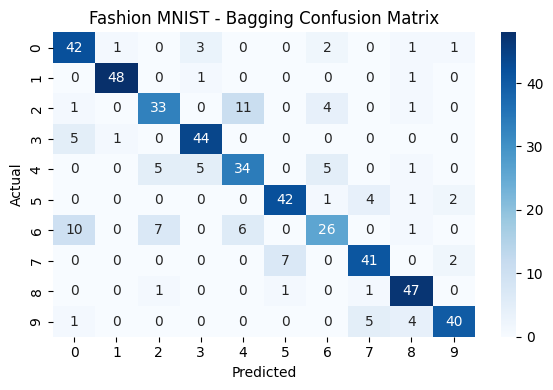


=== MNIST - Gradient Boosting (lr=0.1) ===
Accuracy: 0.4700
Confusion Matrix:
[[31  8  1  0  4  1  2  0  2  0]
 [ 0 41  1  2 10  0  1  0  1  0]
 [ 4  4 11  4  7  0 14  0  5  1]
 [ 1 10  4 25  2  0  1  5  2  1]
 [ 4  0  1  1 28  4  1  2  3  5]
 [ 1  7  4  8  3 13  2  2  1  4]
 [12  1  0  0  7  2 23  0  4  0]
 [ 3  1  0  0  2  1  0 30  0 15]
 [ 3 13  2  9  3  4  0  2 13  0]
 [ 1  0  0  5  1  1  0 20  2 20]]
MAE: 1.816
R2 Score: 0.010583784301518073


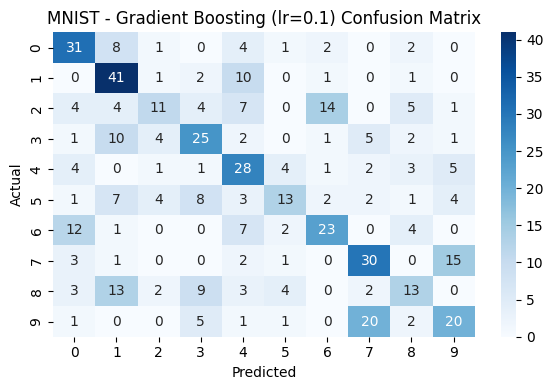


=== Fashion MNIST - Gradient Boosting (lr=0.1) ===
Accuracy: 0.6140
Confusion Matrix:
[[29  0  1  7  0  4  9  0  0  0]
 [ 0 43  0  5  0  1  0  1  0  0]
 [ 4  0 29  1  7  0  6  1  2  0]
 [ 0  0  0 36  7  0  5  0  0  2]
 [ 0  0 19  4 20  0  6  0  1  0]
 [ 0  4  0  0  0 25  0  9  2 10]
 [12  1 10  1  5  0 18  0  3  0]
 [ 0  4  0  0  0  0  0 38  1  7]
 [ 1  1  6  1  8  0  1  4 26  2]
 [ 0  0  0  1  0  1  0  2  3 43]]
MAE: 1.282
R2 Score: 0.3432727272727273


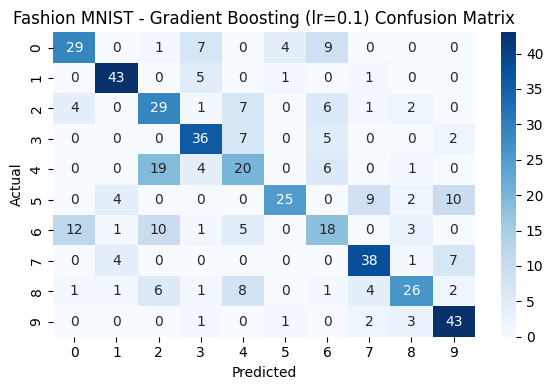

In [27]:
# --- Run Experiments ---

# 1. Bagging (MNIST & Fashion MNIST)
mnist_bagging_preds = bagging_classifier(X_train_mnist, y_train_mnist, X_test_mnist, n_estimators=10)
evaluate_model("MNIST - Bagging", y_test_mnist, mnist_bagging_preds)

fmnist_bagging_preds = bagging_classifier(X_train_fmnist, y_train_fmnist, X_test_fmnist, n_estimators=10)
evaluate_model("Fashion MNIST - Bagging", y_test_fmnist, fmnist_bagging_preds)

# 2. Gradient Boosting (1 learning rate)
mnist_boosting_preds = gradient_boosting_regressor(
    X_train_mnist, y_train_mnist, X_test_mnist, n_estimators=20, learning_rate=0.1)
evaluate_model("MNIST - Gradient Boosting (lr=0.1)", y_test_mnist,
               mnist_boosting_preds, is_boosting=True)

fmnist_boosting_preds = gradient_boosting_regressor(
    X_train_fmnist, y_train_fmnist, X_test_fmnist, n_estimators=20, learning_rate=0.1)
evaluate_model("Fashion MNIST - Gradient Boosting (lr=0.1)", y_test_fmnist,
               fmnist_boosting_preds, is_boosting=True)
